# Logistical analysis of sales data using Python

Loading, cleaning, and analyzing a global retail dataset in Python to investigate shipping performance and profitability, with a machine learning model to predict order profitability.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_excel('SAC Retailer Dataset.xlsx')

data.head()

,Primary ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,Latitude,...,Category,Quantity,Discount,Sales,Profit,Shipping Costs,Storage Costs,Personnel Cost,Selling Costs,Purchasing Costs
0,20534,39747,2020-03-18,2020-03-23,Basic,Sau11472,Saul Fischer,Consumer,Sydney,-33.8650,...,Camera,14,0.1,21000.0,-1634.78,5228.94,4525.51,3829.28,5743.92,3307.13
1,24398,42589,2020-04-04,2020-04-08,Standard,Tan13827,Taniyah Ramsey,Corporate,Adelaide,-34.9289,...,Camera,11,0.1,14850.0,2639.82,2626.97,2587.46,2108.30,3066.62,1820.83
2,27411,75748,2020-05-28,2020-06-01,Basic,May14607,Mayra Sanders,Corporate,Sydney,-33.8650,...,TV,13,0.1,15392.0,1692.54,4906.38,2549.99,2022.40,2813.78,1406.91
3,15393,2637213,2020-01-15,2020-01-19,Standard,Lil18882,Lilian Prince,Consumer,Stockton-on-Tees,54.5700,...,Camera,13,0.0,12610.0,252.20,2563.57,2448.55,2056.78,2840.32,2448.58
4,36695,161422,2020-06-28,2020-07-05,Standard,Ann12237,Annabella Kirk,Consumer,Philadelphia,40.0077,...,TV,14,0.4,8400.0,1175.79,1517.19,1483.82,1369.68,1769.17,1084.35


## Looking for errors and cleaning data:

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20281 entries, 0 to 20280
Data columns (total 29 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Primary ID        20281 non-null  int64         
 1   Order ID          20281 non-null  int64         
 2   Order Date        20281 non-null  datetime64[us]
 3   Ship Date         20281 non-null  datetime64[us]
 4   Ship Mode         20281 non-null  str           
 5   Customer ID       20281 non-null  str           
 6   Customer Name     20281 non-null  str           
 7   Segment           20281 non-null  str           
 8   City              20281 non-null  str           
 9   Latitude          20281 non-null  float64       
 10  Longitude         20281 non-null  float64       
 11  State             20281 non-null  str           
 12  Region            20281 non-null  str           
 13  ISO3              20281 non-null  str           
 14  Country           20281 non-null 

In [4]:
## Convert the date columns into actual date format
data['Order Date'] = pd.to_datetime(data['Order Date'])
data['Ship Date'] = pd.to_datetime(data['Ship Date'])

## Create a delay column
data['Delay'] = (data['Ship Date'] - data['Order Date']).dt.days
data['Delay'].describe()


count    20281.000000
mean        -2.804793
std         69.198023
min       -729.000000
25%          3.000000
50%          4.000000
75%          5.000000
max         38.000000
Name: Delay, dtype: float64

In [5]:
(data['Delay'] < 0).sum()

np.int64(268)

In [6]:
data[data['Delay'] < 0]['Delay'].value_counts().sort_index()

Delay
-729     9
-728    10
-727    36
-726    30
-725    36
-724    25
-698     7
-697     9
-696    11
-695     7
-694     4
-693     3
-30      1
-29     10
-28      6
-27     15
-26     23
-25     10
-24     16
Name: count, dtype: int64

In [7]:
data[['Sales','Profit','Quantity','Discount']].describe()

,Sales,Profit,Quantity,Discount
count,20281.000000,20281.000000,20281.000000,20281.000000
mean,1214.771377,108.731929,3.477935,0.146547
std,1537.036188,690.094540,2.274964,0.210535
min,20.000000,-15971.820000,1.000000,0.000000
25%,162.000000,0.000000,2.000000,0.000000
50%,636.000000,49.390000,3.000000,0.000000
75%,1700.000000,267.910000,5.000000,0.200000
max,21000.000000,8279.560000,14.000000,0.800000


In [8]:
cleaned_data = data[data['Delay'] >= 0].copy()

From 20,281 rows to 20,013 after cleaning data

## Which shipping mode is used the most? Which is actually faster?

In [9]:
cleaned_data['Ship Mode'].value_counts()

Ship Mode
Standard    11843
Basic        4120
Prime        2945
Express      1105
Name: count, dtype: int64

In [10]:
cleaned_data.groupby('Ship Mode')['Delay'].mean().sort_values()

Ship Mode
Express     0.033484
Prime       2.270289
Basic       3.225971
Standard    5.045597
Name: Delay, dtype: float64

In [11]:
cleaned_data.groupby('Ship Mode')['Delay'].agg(['mean', 'median'])

,mean,median
Ship Mode,,
Basic,3.225971,3.0
Express,0.033484,0.0
Prime,2.270289,2.0
Standard,5.045597,5.0


Standard is the most used, followed by Basic, then Prime, then Express.
Everything seems fine, the more expensive the shipping mode is, the less its picked
The more expensive the shipping mode, the faster it is

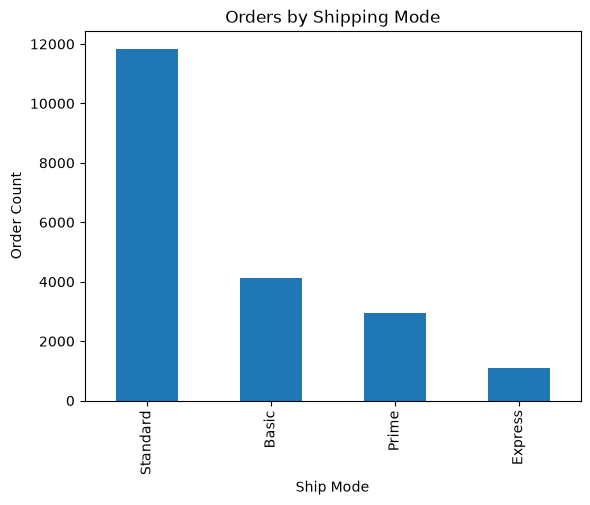

In [12]:
order = ['Standard', 'Basic', 'Prime', 'Express']
cleaned_data['Ship Mode'].value_counts()[order].plot(kind = 'bar', title = 'Orders by Shipping Mode')
plt.ylabel('Order Count')
plt.savefig('orders_by_ship_mode.png', dpi=150, bbox_inches='tight')
plt.show()

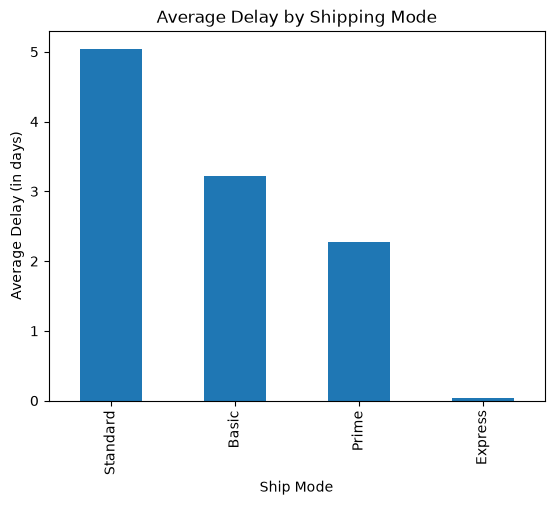

In [13]:
cleaned_data.groupby('Ship Mode')['Delay'].mean()[order].plot(kind = 'bar', title = 'Average Delay by Shipping Mode')
plt.ylabel('Average Delay (in days)')
plt.savefig('average_delay_by_ship_mode.png', dpi=150, bbox_inches='tight')
plt.show()

## Is Express expensive to offer? Does the slowness of Standard translate into any cost savings?

In [14]:
## Finding the shipping cost by shipping mode
cleaned_data.groupby('Ship Mode')['Shipping Costs'].mean().sort_values()

Ship Mode
Express     148.495321
Prime       155.390543
Standard    158.948484
Basic       159.034709
Name: Shipping Costs, dtype: float64

The shipping cost is basically the same across all four shipping modes, 
Only really having a $11 difference between the cheapest and most expensive

In [15]:
## Finding the profit margin
cleaned_data['Profit Margin'] = cleaned_data['Profit'] / cleaned_data['Sales']
cleaned_data.groupby('Ship Mode')[['Profit', 'Profit Margin']].mean()

,Profit,Profit Margin
Ship Mode,,
Basic,95.914602,0.030643
Express,112.077186,0.041044
Prime,123.760445,0.050661
Standard,109.693985,0.052674


Standard has the highest profit margin, along with being the most used mode
Prime is the second highest profit margin
Express is the third highest
Basic has the lowest margin, it isnt the fastest or the slowest either

So the shipping cost doesnt differ by shipping mode 

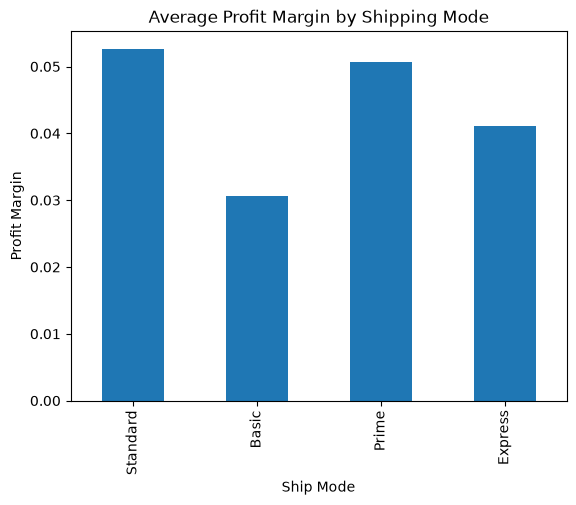

In [16]:
cleaned_data.groupby('Ship Mode')['Profit Margin'].mean()[order].plot(kind = 'bar', title = 'Average Profit Margin by Shipping Mode')
plt.ylabel('Profit Margin')
plt.savefig('profit_margin_by_ship_mode.png', dpi=150, bbox_inches='tight')
plt.show()

## Does Discount have something to do with it?

In [17]:
cleaned_data.groupby('Ship Mode')['Discount'].mean().sort_values()

Ship Mode
Express     0.137792
Basic       0.139221
Standard    0.148556
Prime       0.149623
Name: Discount, dtype: float64

Discount has a small range too, so thats not the reason for why the margin varies by shipping mode

In [18]:
## Checking the cost columns
cleaned_data.groupby('Ship Mode')[['Storage Costs', 'Personnel Cost', 'Selling Costs', 'Purchasing Costs']].mean()

,Storage Costs,Personnel Cost,Selling Costs,Purchasing Costs
Ship Mode,,,,
Basic,250.610267,229.251490,278.842964,205.362813
Express,245.045339,223.828561,269.534326,201.130217
Prime,237.162211,217.101304,263.080441,196.248350
Standard,247.900567,225.795829,274.207906,202.949260


Basic orders carry the highest average costs across every other cost category, while Prime carries the lowest, which matches with their margin rankings. Discounts and shipping cost arnt a real player here as they are flat across all the shipping modes.

## Does this shipping mode pattern hold across markets? or does it break down in specific regions?

In [19]:
## Shipping mode usage vary by market?
pd.crosstab(cleaned_data['Market'], cleaned_data['Ship Mode'], normalize='index')

Ship Mode,Basic,Express,Prime,Standard
Market,,,,
APAC,0.202469,0.041270,0.150265,0.605996
Africa,0.245007,0.051145,0.143205,0.560643
Australia,0.223266,0.065029,0.131503,0.580202
EME,0.200206,0.058257,0.140574,0.600962
LATAM,0.205059,0.055974,0.145587,0.593380
NAR,0.191869,0.058488,0.162625,0.587019


In [20]:
## Delay by ship mode accross markets
cleaned_data.groupby(['Market', 'Ship Mode'])['Delay'].mean().unstack()

Ship Mode,Basic,Express,Prime,Standard
Market,,,,
APAC,3.191638,0.025641,2.180751,4.961583
Africa,3.282306,0.028571,2.251701,4.969592
Australia,3.427184,0.022222,2.038462,4.967621
EME,3.177682,0.026549,2.411980,5.156992
LATAM,3.215223,0.043269,2.238447,4.986395
NAR,3.218092,0.044715,2.251462,5.059943


In [21]:
## Profit Margin by shipping mode accross markets
cleaned_data.groupby(['Market', 'Ship Mode'])['Profit Margin'].mean().unstack()

Ship Mode,Basic,Express,Prime,Standard
Market,,,,
APAC,0.023406,0.058750,0.084381,0.052527
Africa,0.006226,-0.047476,-0.017183,0.021945
Australia,0.062993,-0.040068,0.024605,0.078225
EME,0.029396,0.054316,0.036750,0.051472
LATAM,0.053043,0.097456,0.051147,0.045110
NAR,0.019275,0.034093,0.082008,0.067249


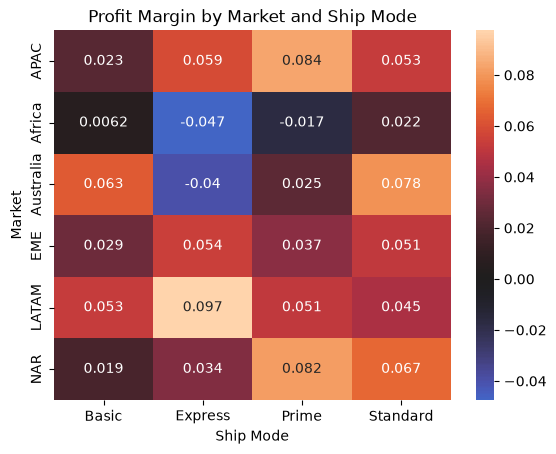

In [22]:
sns.heatmap(cleaned_data.groupby(['Market', 'Ship Mode'])['Profit Margin'].mean().unstack(), annot = True, center = 0)
plt.title('Profit Margin by Market and Ship Mode')
plt.savefig('market_and_ship_mode_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Why do Africa and Australia go negative?

In [23]:
# The order count for every Market and ship mode
cleaned_data.groupby(['Market', 'Ship Mode']).size().unstack()

Ship Mode,Basic,Express,Prime,Standard
Market,,,,
APAC,574,117,426,1718
Africa,503,105,294,1151
Australia,309,90,182,803
EME,1165,339,818,3497
LATAM,762,208,541,2205
NAR,807,246,684,2469


In [24]:
# Making the negative areas their own variables
africa_express = cleaned_data[(cleaned_data['Market'] == 'Africa') & (cleaned_data['Ship Mode'] == 'Express')]
africa_prime = cleaned_data[(cleaned_data['Market'] == 'Africa') & (cleaned_data['Ship Mode'] == 'Prime')]
australia_express = cleaned_data[(cleaned_data['Market'] == 'Australia') & (cleaned_data['Ship Mode'] == 'Express')]

In [25]:
# Comparing the cost structure against express mode globally
cleaned_data[cleaned_data['Ship Mode'] == 'Express'][['Shipping Costs', 'Storage Costs', 'Personnel Cost', 'Selling Costs', 'Purchasing Costs', 'Discount']].mean()

Shipping Costs      148.495321
Storage Costs       245.045339
Personnel Cost      223.828561
Selling Costs       269.534326
Purchasing Costs    201.130217
Discount              0.137792
dtype: float64

In [26]:
# Comparing the cost structure against prime mode globally
cleaned_data[cleaned_data['Ship Mode'] == 'Prime'][['Shipping Costs', 'Storage Costs', 'Personnel Cost', 'Selling Costs', 'Purchasing Costs', 'Discount']].mean()

Shipping Costs      155.390543
Storage Costs       237.162211
Personnel Cost      217.101304
Selling Costs       263.080441
Purchasing Costs    196.248350
Discount              0.149623
dtype: float64

In [27]:
# Cost structure on africa_express
africa_express[['Shipping Costs', 'Storage Costs', 'Personnel Cost', 'Selling Costs', 'Purchasing Costs', 'Discount']].mean()

Shipping Costs       77.487905
Storage Costs       183.157238
Personnel Cost      170.245905
Selling Costs       198.977048
Purchasing Costs    151.846190
Discount              0.169524
dtype: float64

In [28]:
# Cost structure on africa_prime
africa_prime[['Shipping Costs', 'Storage Costs', 'Personnel Cost', 'Selling Costs', 'Purchasing Costs', 'Discount']].mean()

Shipping Costs       90.931803
Storage Costs       150.764422
Personnel Cost      137.967177
Selling Costs       164.609762
Purchasing Costs    125.284014
Discount              0.165306
dtype: float64

In [29]:
# Cost structure on australia_express
australia_express[['Shipping Costs', 'Storage Costs', 'Personnel Cost', 'Selling Costs', 'Purchasing Costs', 'Discount']].mean()

Shipping Costs      205.490333
Storage Costs       259.156444
Personnel Cost      238.339889
Selling Costs       283.478667
Purchasing Costs    210.627222
Discount              0.126667
dtype: float64

The costs of express shipping in Australia are higher everywhere compared to the global express baseline. On top of all of that the discount is lower, so that means the reason why it is negative is just because everything costs more there, which is probably because of their geographic location.

Africa however, the cost columns are lower than the global baseline for both express shipping and prime shipping. Which means that it isnt expensive to ship stuff to Africa. The discount in Africa for both express and prime is higher than the global baseline. So if Africa is getting less sales, that would make sense along with the higher discount rates causes it to go negative

In [30]:
for name, df_slice in [('Express global', cleaned_data[cleaned_data['Ship Mode']=='Express']),
                        ('Africa Express', africa_express),
                        ('Africa Prime', africa_prime),
                        ('Australia Express', australia_express)]:
    print(name, df_slice['Sales'].mean())

Express global 1200.1109502262445
Africa Express 766.2514285714285
Africa Prime 733.9363945578231
Australia Express 1275.3255555555556


The average sales for africa are far below the global baseline for express, compared to australia's which are slightly above the global baseline for express. So Australia loses money because of the high costs it takes to get there, while Africa loses money because the order values are much smaller so the costs consume a disprportionate share of the revenue

## Predicting whether or not an order is profitable or not

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [32]:
cleaned_data['Profitable'] = (cleaned_data['Profit'] > 0).astype(int)
cleaned_data['Profitable'].value_counts(normalize = True)

Profitable
1    0.73922
0    0.26078
Name: proportion, dtype: float64

73.9% are profitable while 26% arnt, so the model needs to beat that

In [33]:
# Excluding sales because its too closely tied to profit, inflates the data
cols = ['Ship Mode', 'Market', 'Discount', 'Quantity', 'Shipping Costs', 'Storage Costs', 'Personnel Cost', 'Selling Costs', 'Purchasing Costs']

x = pd.get_dummies(cleaned_data[cols], columns = ['Ship Mode', 'Market'], drop_first = True)
y = cleaned_data['Profitable']
x.head()

,Discount,Quantity,Shipping Costs,Storage Costs,Personnel Cost,Selling Costs,Purchasing Costs,Ship Mode_Express,Ship Mode_Prime,Ship Mode_Standard,Market_Africa,Market_Australia,Market_EME,Market_LATAM,Market_NAR
0,0.1,14,5228.94,4525.51,3829.28,5743.92,3307.13,False,False,False,False,True,False,False,False
1,0.1,11,2626.97,2587.46,2108.30,3066.62,1820.83,False,False,True,False,True,False,False,False
2,0.1,13,4906.38,2549.99,2022.40,2813.78,1406.91,False,False,False,False,True,False,False,False
3,0.0,13,2563.57,2448.55,2056.78,2840.32,2448.58,False,False,True,False,False,True,False,False
4,0.4,14,1517.19,1483.82,1369.68,1769.17,1084.35,False,False,True,False,False,False,False,True


In [34]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [35]:
model = RandomForestClassifier(random_state = 42)
model.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [36]:
y_prediction = model.predict(x_test)
print(classification_report(y_test, y_prediction))

              precision    recall  f1-score   support

           0       0.73      0.52      0.61      1074
           1       0.84      0.93      0.88      2929

    accuracy                           0.82      4003
   macro avg       0.79      0.73      0.75      4003
weighted avg       0.81      0.82      0.81      4003



In [37]:
importances = pd.Series(model.feature_importances_, index = x.columns).sort_values(ascending = False)
importances

Shipping Costs        0.205995
Storage Costs         0.151131
Personnel Cost        0.149758
Selling Costs         0.144374
Purchasing Costs      0.138286
Quantity              0.097594
Discount              0.041124
Ship Mode_Standard    0.013338
Market_EME            0.011440
Market_NAR            0.009956
Market_LATAM          0.009512
Ship Mode_Prime       0.009356
Market_Africa         0.006504
Market_Australia      0.006000
Ship Mode_Express     0.005631
dtype: float64

The model was able to go past the 73.9% accuracy and hit 82%. The cost coloumns are the main things dominating the feature importance, discount and the africa and australia markets ranking near the bottom

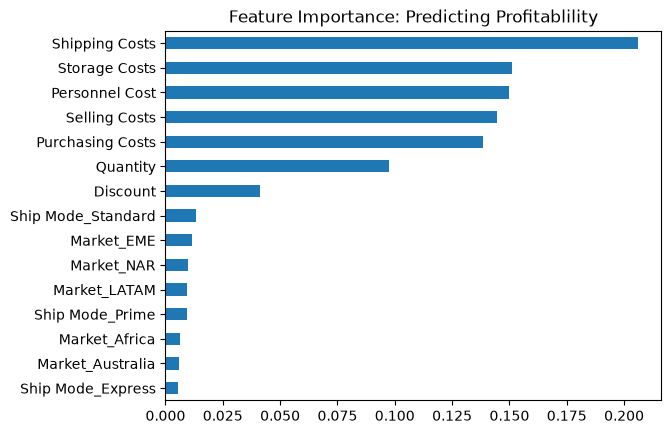

In [38]:
importances.sort_values().plot(kind = 'barh', title = 'Feature Importance: Predicting Profitablility')
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

Shipping speeds and usage were expected, the faster the shipping speed the less its used. The differences in margin comes down to the cost structure instead of shipping cost or discount, this holds up for everywhere except in Africa and Australia. This is mostly because of the high costs in Australia and the undersized orders in Africa. The random forest model confirmed that the strongest predictors of profitability are the costs, however it didnt independently flag what happened in Africa or Australia.